In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from epics import PV

In [2]:
SSMBamplavg = PV('SCOPE1ZULP:h1p1:rdAmplAv')
SSMBampldev = PV('SCOPE1ZULP:h1p1:rdAmplDev')
SSMBavglen  = PV('SCOPE1ZULP:rdAvLength')

In [4]:
AK01 = PV('AKC01VP')

In [5]:
def AK01cbf(list01=None, listSSMBavg=None, listSSMBsem=None, value=None, **kwargs):
    if value == 0:
        listSSMBavg.append(SSMBamplavg.get())
        listSSMBsem.append(SSMBampldev.get()/SSMBavglen.get()**0.5) 
    else:
        list01.append(value)

In [74]:
### start taking data ###
edgelist = []
SSMBavglist = []
SSMBsemlist = []
AK01cb = AK01.add_callback(AK01cbf, list01=edgelist, listSSMBavg=SSMBavglist, listSSMBsem=SSMBsemlist)

In [77]:
### stop taking data make and save df ###
index=0
date ='TEST'
df = pd.DataFrame({'egdeposition':edgelist, 'SSMBsignal':SSMBavglist, 'SSMBerror':SSMBsemlist})
print(df)
df.to_hdf(f'{date}_edgescan_{index}.hdf5', key='data')

    egdeposition  SSMBsignal  SSMBerror
0           15.0    0.007223   0.000684
1           14.5    0.019785   0.001563
2           14.0    0.034355   0.001010
3           13.5    0.038418   0.002702
4           13.0    0.057344   0.002961
5           12.5    0.076895   0.002773
6           12.0    0.097383   0.002245
7           11.5    0.095742   0.003715
8           11.0    0.116836   0.004649
9           10.5    0.139023   0.003615
10          10.0    0.121094   0.008000
11           9.5    0.134863   0.004959
12           9.0    0.155762   0.008203
13           8.5    0.156934   0.007772
14           8.0    0.173633   0.007405


In [75]:
edgelist

[15.0]

In [76]:
SSMBavglist

[]

In [18]:
df0 = pd.read_hdf('2024-07-15_edgescan_0.hdf5')
df1 = pd.read_hdf('2024-07-15_edgescan_1.hdf5')

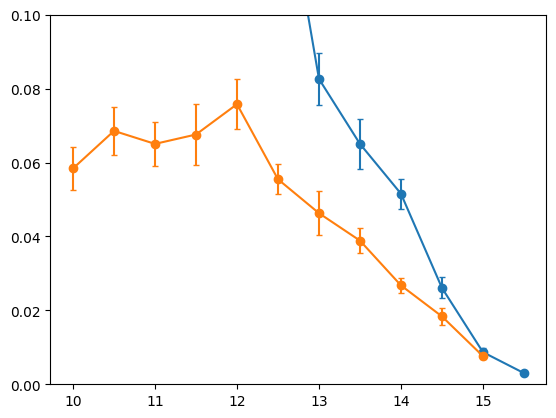

In [25]:
plt.errorbar(df0.egdeposition, df0.SSMBsignal, df0.SSMBerror, marker='o', capsize=2)
plt.errorbar(df1.egdeposition, df1.SSMBsignal, df1.SSMBerror, marker='o', capsize=2)
plt.ylim(0,0.1)
plt.show()

In [41]:
df2 = pd.read_hdf('2024-07-15_edgescan_2.hdf5')
df3 = pd.read_hdf('2024-07-15_edgescan_3.hdf5')

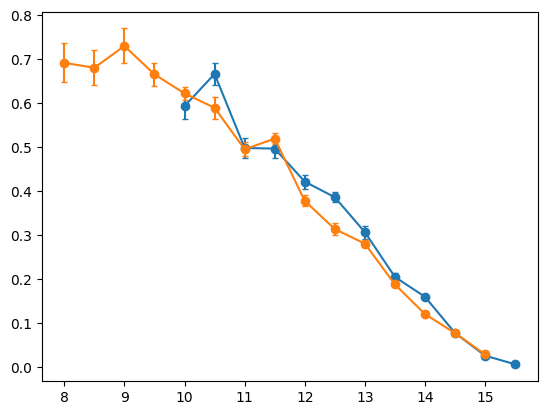

In [43]:
plt.errorbar(df2.egdeposition, df2.SSMBsignal, df2.SSMBerror, marker='o', capsize=2)
plt.errorbar(df3.egdeposition, df3.SSMBsignal, df3.SSMBerror, marker='o', capsize=2)
# plt.ylim(0,0.1)
plt.show()

In [60]:
df4 = pd.read_hdf('2024-07-15_edgescan_4.hdf5')
df5 = pd.read_hdf('2024-07-15_edgescan_5.hdf5')

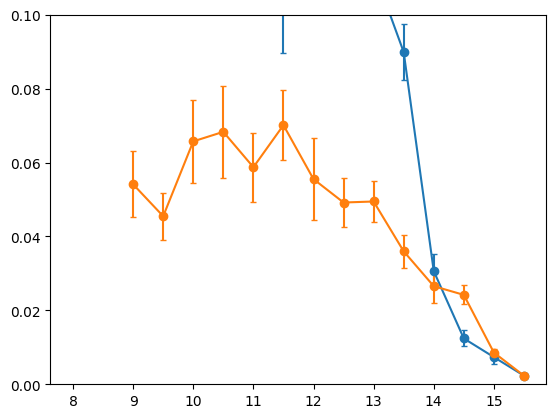

In [64]:
plt.errorbar(df4.egdeposition, df4.SSMBsignal, df4.SSMBerror, marker='o', capsize=2)
plt.errorbar(df5.egdeposition, df5.SSMBsignal, df5.SSMBerror, marker='o', capsize=2)
plt.ylim(0,0.1)
plt.show()

In [79]:
df6 = pd.read_hdf('2024-07-15_edgescan_6.hdf5')
df7 = pd.read_hdf('2024-07-15_edgescan_7.hdf5')

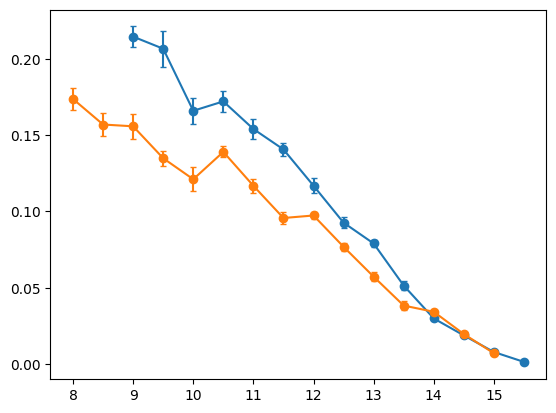

In [81]:
plt.errorbar(df6.egdeposition, df6.SSMBsignal, df6.SSMBerror, marker='o', capsize=2)
plt.errorbar(df7.egdeposition, df7.SSMBsignal, df7.SSMBerror, marker='o', capsize=2)
# plt.ylim(0,0.1)
plt.show()

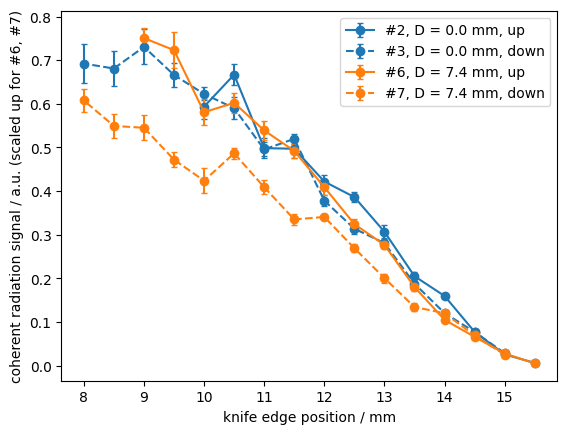

In [96]:
plt.errorbar(df2.egdeposition, df2.SSMBsignal, df2.SSMBerror, marker='o', capsize=2, ls='-', color='C0', label='#2, D = 0.0 mm, up')
plt.errorbar(df3.egdeposition, df3.SSMBsignal, df3.SSMBerror, marker='o', capsize=2, ls='--', color='C0', label='#3, D = 0.0 mm, down')
plt.errorbar(df6.egdeposition, df6.SSMBsignal*3.5, df6.SSMBerror*3.5, marker='o', capsize=2, ls='-', color='C1', label='#6, D = 7.4 mm, up')
plt.errorbar(df7.egdeposition, df7.SSMBsignal*3.5, df7.SSMBerror*3.5, marker='o', capsize=2, ls='--', color='C1', label='#7, D = 7.4 mm, down')
# plt.ylim(0,0.1)
plt.legend()
plt.xlabel('knife edge position / mm')
plt.ylabel('coherent radiation signal / a.u. (scaled up for #6, #7)')
plt.show()